# BBC News Classification Kaggle Mini-Project



## Kaggle Competition: BBC News Classification 

This Kaggle competition is about categorizing news articles. We shall primarily use unsupervised machine learning, more precisely, the matrix factorization techniques (e.g., **truncated SVD**, **NMF**) to predict the category of a news article. Also, we shall compare the unsupervised ML model's performance (trained on the training dataset) in terms of classification accuracy (on held-out test dataset) and analyze the shortcomings of the models.

We shall execute the following steps to achieve the text classification task:

* start with exploratory data analysis (EDA) procedure (inspect, visualize and clean the noisy text dataset) - a mandatory step prior to the actual data analysis can begin
* preprocess the dataset - to extract relevant features (e.g., we shall extract **bag-of-words** and **tf-idf** features with `scikit-learn`)
* formulate the text classification problem as topic modeling (extraction) probelm, build couple of unsupervised models based on martix factorization (namely, **truncated SVD** and **non-negative matrix factorization**) with `scikit-learn`, in order to extract the topics from the articles in an unsupervised manner (i.e., we shall not use the categories provided), and train them on the training text dataset. We shall use the models to predict the category of the test aricles.
* build a few supervised multi-class classification models (e.g., **random forest**, **support vector machine** and **gradient boosting**), train them on the training dataset (this time using the categories as the class labels).  We shall use the models to predict the category of the test aricles.
*  for **model selection** we shall use a held-out **validation** set from the training dataset, which we shall use to evaluate our models.
* finally we shall compare the unsupervised vs. the supervised learning models in terms of the performace on the test dataset (*kaggle leaderboard score*). 

# Part 1

## Exploratory Data analysis (EDA) 
###  Inspect, Visualize and Clean the Data 

First we need to import all `python` packages / functions (need to install with `pip` if some of them are not already installed) that are required to the clean the texts (from the tweets), for building the RNN models and for visualization. We shall use `tensorflow / keras` to to train the deep learning models. 

In [ ]:
import numpy as np 
import pandas as pd 
import os, math

#for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

#for text cleaning / preprocessing
import string, re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

#for data analysis and modeling
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn import decomposition

import warnings
warnings.filterwarnings('ignore')

### Inspect

Read the train and test dataframe, the only columns that we shall use are *text* (to extract input features) and *target* (output to predict).

In [119]:
df_train = pd.read_csv('learn-ai-bbc/BBC News Train.csv') #, index_col='id')
df_test = pd.read_csv('learn-ai-bbc/BBC News Test.csv') #, index_col='id')
df_train.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [39]:
df_test.head()

,ArticleId,Text
0,1018,qpr keeper day heads for preston queens park r...
1,1319,software watching while you work software that...
2,1138,d arcy injury adds to ireland woe gordon d arc...
3,459,india s reliance family feud heats up the ongo...
4,1020,boro suffer morrison injury blow middlesbrough...


There are 1490 tweets in the training and 736 tweets in the test dataset, respectively.

In [40]:
df_train.shape, df_test.shape

((1490, 3), (735, 2))

Maximum number of words present in a tweet is 3345 and 4492, in training and test dataset, respectively.

In [41]:
max_len_train = max(df_train['Text'].apply(lambda x: len(x.split())).values)
max_len_test = max(df_test['Text'].apply(lambda x: len(x.split())).values)
max_len_train, max_len_test

(3345, 4492)

### Visualize

The following plot shows histogram of class labels, the number of positive (disaster) and negative (no distaster) classes in the training dataset. As can be seen, the dataset is slightly imbalanced.

5


,Category,count
0,sport,346
1,business,336
2,politics,274
3,entertainment,273
4,tech,261


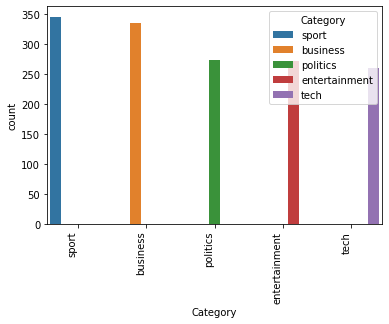

In [42]:
freq_df = pd.DataFrame(df_train['Category'].value_counts()).reset_index()
freq_df.columns = ['Category', 'count']
ncats = len(freq_df)
print(ncats)
ax = sns.barplot(data=freq_df, x='Category', y='count', hue='Category')
ax.set_xticklabels(ax.get_xticklabels(), 
                          rotation=90, 
                          horizontalalignment='right')
plt.margins(x=0.01)
freq_df.head()

### Clean / Preprocess

Since the news article texts are likely to contain many junk characters along with very common non-informative words (*stopwords*, e.g., 'the'), it is a good idea to clean the text (with the function `clean_text()` as shown below) and remove unnecessary stuffs before building the models, otherwise they can affect the performance. The function cleans the input text by following the steps below:

* remove / replace punctuations
* replace numbers, dollar and pound values (very important)
* split into words (tokens)
* remove stopwords
* remove leftover punctuations

It's important that we apply the same preprocessing on both the training and test dataset.

In [120]:
def clean_text(txt):
    
    #remove punctuations
    txt  = "".join([char if char not in string.punctuation else ' ' for char in txt ])
    
    #process numbers / money
    txt = txt.replace('£', '$')
    txt = re.sub("\d+", " NUM ", txt) # change numbers to word " NUM "
    txt = re.sub('\s+', ' ', txt)   
    txt = txt.replace("NUM NUM", "NUM")
    txt = txt.replace("$ NUM", "dollar")
    txt = txt.replace("NUM bn", "dollar")
    txt = txt.replace("dollar bn", "dollar")
    txt = txt.replace("dollar dollar", "dollar")
    txt = txt.replace("NUM", "")
    txt = txt.replace("said", "") # the word said is too frequent, we can see it with word cloud
    
    txt = txt.lower() # lowercase
    
    # split into words
    words = word_tokenize(txt)
    
    # remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if not w in stop_words]
    
    # removing leftover punctuations
    words = [word for word in words if word.isalpha()]
    
    cleaned_text = ' '.join(words)
    return cleaned_text

Clean train and test news articles, using the above function.

In [121]:
df_train['Text'] = df_train['Text'].apply(lambda txt: clean_text(txt))
df_test['Text'] = df_test['Text'].apply(lambda txt: clean_text(txt))

df_train.head()

,ArticleId,Text,Category
0,1833,worldcom ex boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens maj...,business
3,1976,lifestyle governs mobile choice faster better ...,tech
4,917,enron bosses payout eighteen former enron dire...,business


Find the unique categories of new articles, there are $5$ of them.

In [54]:
topics = df_train['Category'].unique()
k = len(topics)
print(k, topics)

5 ['business' 'tech' 'politics' 'sport' 'entertainment']


### Visualize

Now, let's use the `wordcloud` library to find the most frequent words in the news articles corresponding to different categroes, using the function `plot_wirdcloud()` defined below. 

In [59]:
def plot_wordcloud(text, title, k=10):
  # Create and Generate a Word Cloud Image
  wordcloud = WordCloud(width = 3000, height = 2000, random_state=1, background_color='black', colormap='Set2', collocations=False, stopwords = STOPWORDS).generate(text)
  # top k words
  plt.figure(figsize=(10,5))
  print(f'category {cat}, top {k} words: {list(wordcloud.words_.keys())[:k]}')
  ax = sns.barplot(x=0, y=1, data=pd.DataFrame(wordcloud.words_.items()).head(k))
  ax.set(xlabel = 'words', ylabel='count', title=title)
  plt.show()
  #Display the generated image
  plt.figure(figsize=(15,15))
  plt.imshow(wordcloud, interpolation="bilinear"), plt.title(title, size=20), plt.axis("off")
  plt.show()

The next plots show few of the most frequent words for each category of news articles. The following list shows the frequent words from each category of news articles:

* **business** : 'dollar', 'firm', 'market', 'sale'.
* **tech** : 'mobile', 'phone', 'service', 'newtowrk', 'software'.
* **politics** : 'labour', 'election', 'government', 'party'.
* **sport** : 'game', 'player', 'win', 'team'.
* **entertainment** : 'film', 'show', 'award', 'music'.

category business, top 10 words: ['dollar', 'year', 'us', 'mr', 'firm', 'new', 'market', 'sale', 'growth', 'company']


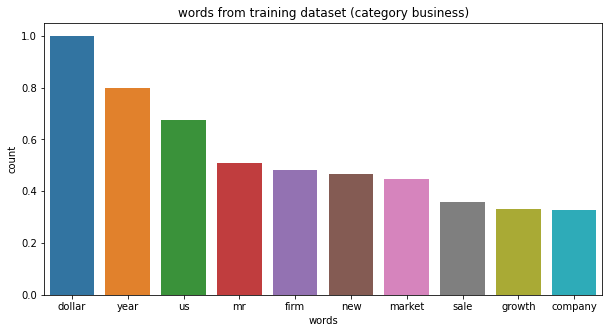

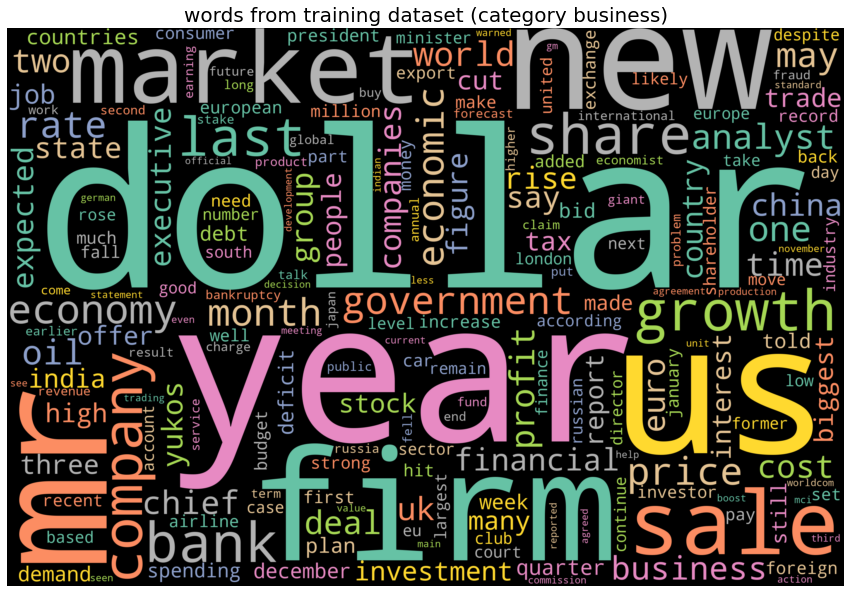

category tech, top 10 words: ['people', 'new', 'mobile', 'phone', 'game', 'service', 'one', 'year', 'mr', 'user']


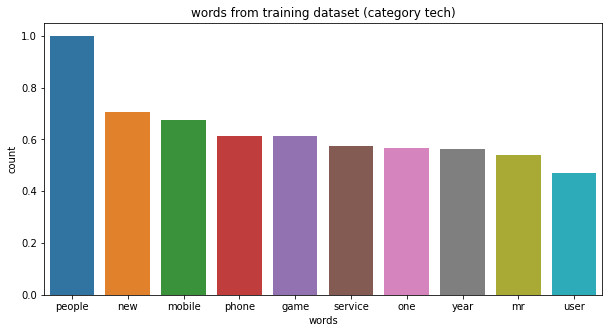

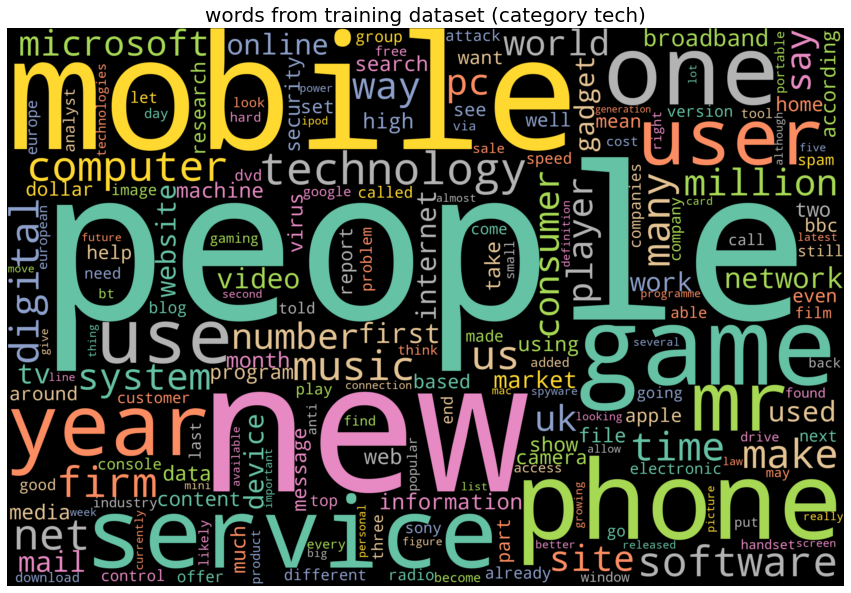

category politics, top 10 words: ['mr', 'labour', 'election', 'government', 'blair', 'party', 'minister', 'people', 'new', 'say']


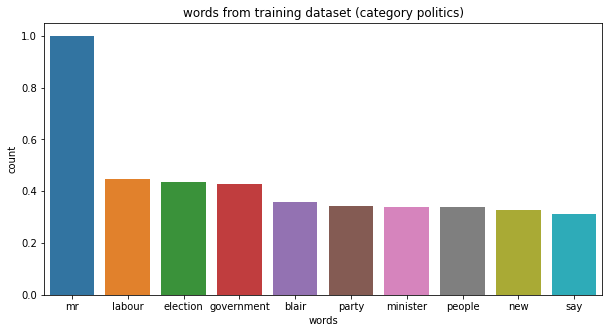

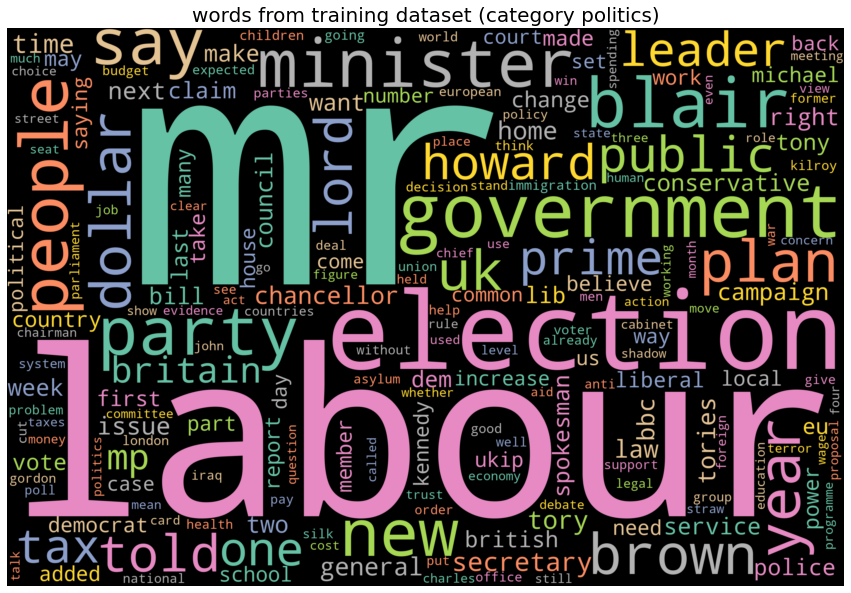

category sport, top 10 words: ['game', 'year', 'first', 'win', 'time', 'england', 'player', 'two', 'back', 'world']


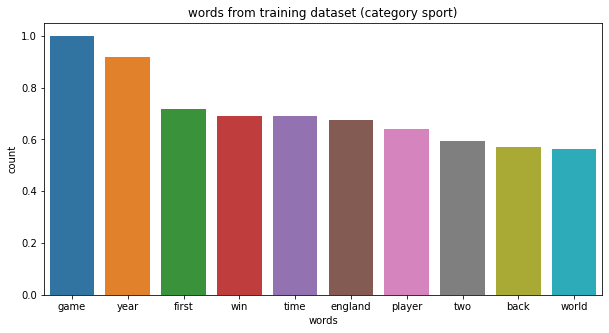

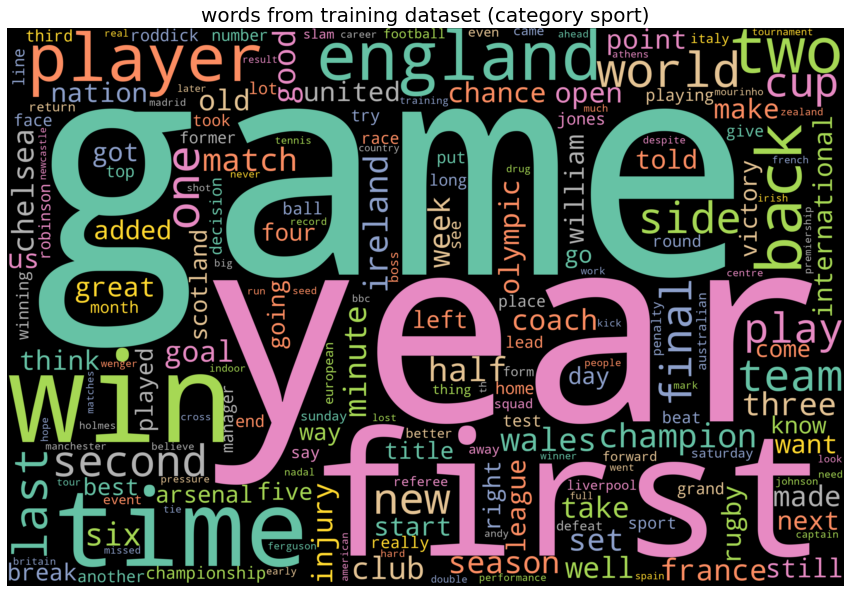

category entertainment, top 10 words: ['film', 'year', 'best', 'award', 'one', 'show', 'new', 'us', 'star', 'music']


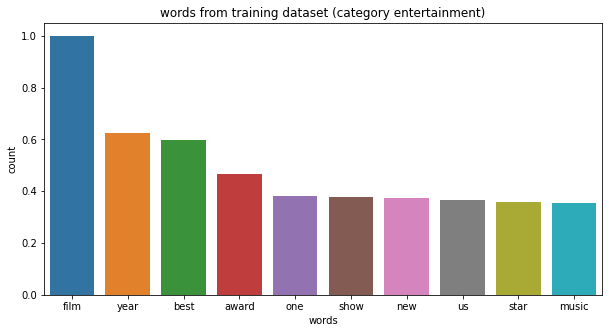

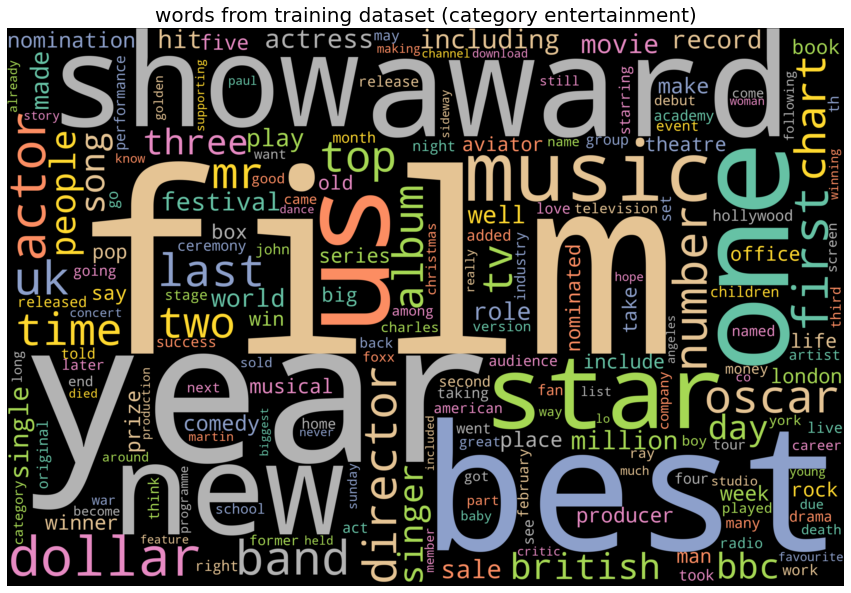

In [60]:
for cat in df_train['Category'].unique():
    plot_wordcloud(' '.join(df_train[df_train['Category']==cat]['Text'].values), f'words from training dataset (category {cat})')

Our goal will be to find the topics from the news articles without using the ground-truth categories, using the topic models, where a topic will correspond to a category.

## Extracting word features 

Before we can start building models, we must process raw texts to feature vectors. Here we shall extract 

* **bag-of-words** features and (with `CountVectorizer`), which represents a word (term) using its frequency (**TF**).
* **term-freq / inverse-doc-freq** (with `TfidfVectorizer`), where a word is represented using its **TFIDF** score, 

as shown in the below figure, using the `sklearn.feature_extraction.text` module. 

![](tfidf.png)

* We shall only consider the top `max_features=5000` features ordered by term frequency across the news articles.
* Since the words that are present in the test dataset articles but not in training dataset articles can't be associated with the ground-truth trainign categories, it's best to ignore them and train the vectorizers on the train dataset only.
* When building the vocabulary we shall ignore terms that have a news article frequency strictly higher than $2$ and less than $95\%$ of the news articles.

In [84]:
n_feats = 5000
cvectorizer = CountVectorizer(stop_words='english', max_features=n_feats) #, tokenizer=LemmaTokenizer())
tvectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2, max_features=n_feats) #, tokenizer=LemmaTokenizer())

## Model Building

Let's start by creating a train dataset where the model will be trained, and a valdation dataset where the model will be  evaluated on (by matching with the categories provided).

### Create Train and Validation Dataset

* Let's hold out a small portion ($10\%$) of the dataset to be treated as unseen validation dataset and shall be used later for model evaluation. 

* Let's split the given training dataset further into train and validation dataset, only the train split will be used for model training purpose.

In [78]:
X_train, y_train, X_test = df_train['Text'].values, df_train['Category'].values, df_test['Text'].values
X_train_, X_val_, y_train_, y_val_ = train_test_split(X_train, y_train, test_size=0.1, random_state=0)
X_train.shape, X_train_.shape

((1490,), (1341,))

Next let's try the **unsupervised models** based on **matrix factorization** to automatically extract latent topics in the the dataset and then match them with the provided categories.

## Unsupervised (Matrix Factorization) Models

We shall build a couple of different matrix factorization models, namely 

1. Truncated Singular Value Decomposition (**TSVD**) 
2. Non-Negative Matric Factoriation (**NMF**)

### 1. Truncated SVD

Let's fit  a truncated SVD model to extract $5$ latent topics, we shall use the *bag-of-words* features this time.

In [82]:
tsvd = decomposition.TruncatedSVD(n_components=k, algorithm='randomized', n_iter=20, random_state=0)

vectors = cvectorizer.fit_transform(X_train_).todense() # (documents, vocab)
vocab = np.array(cvectorizer.get_feature_names_out())
vectors.shape, vocab.shape, vocab[:10]

((1341, 5000),
 (5000,),
 array(['abbas', 'ability', 'able', 'abroad', 'absence', 'absolute',
        'absolutely', 'abuse', 'abused', 'ac'], dtype=object))

The function `show_words_for_topics()` returns top $10$ words for a given topic.

In [83]:
def show_words_for_topics(topic, num_top_words = 10):
    return np.apply_along_axis(lambda x: vocab[(np.argsort(-x))[:num_top_words]], 1, topic)

tsvd.fit(vectors)
topics = tsvd.components_
print(topics.shape)

print(show_words_for_topics(topics))

(5, 5000)
[['mr' 'people' 'dollar' 'new' 'year' 'government' 'time' 'uk' 'labour'
  'world']
 ['mr' 'labour' 'blair' 'party' 'election' 'brown' 'minister' 'kilroy'
  'government' 'prime']
 ['dollar' 'wage' 'minimum' 'increase' 'pay' 'tax' 'government' 'jobs'
  'business' 'paid']
 ['best' 'film' 'dollar' 'actor' 'director' 'actress' 'awards' 'year'
  'win' 'aviator']
 ['roddick' 'nadal' 'game' 'england' 'break' 'set' 'point' 'serve'
  'ireland' 'match']]


From the top words (with heighest weights) for the above $5$ latent topics, the last $3$ of them clearly corresponds to `business`, `entertainment` and `sport`, but the first two are not clear. Still assigning a category for the first two, we get the following topic dictionary.

In [75]:
topic_dict = {0: 'tech', 1: 'politics', 2: 'business', 3: 'entertainment', 4: 'sport'}

Also, note that the data is still pretty noisy and TSVD can only explain a small percentage of variance in the data.

In [74]:
print(tsvd.explained_variance_ratio_)
print(tsvd.explained_variance_ratio_.sum())
print(tsvd.singular_values_)

[0.02561559 0.02636912 0.02167606 0.01908583 0.0168965 ]
0.10964309909422594
[196.85488794 120.73593918 108.83479115 101.9456552   95.21317426]


### Measure the performances of predictions

Now, let's predict the categories of the articles in the training and validation dataset, using the model (corresponding to the topic with the highest weight). As can be seen, both training and validation accuracies are poor, so this model performs poorly for the dataset. 

In [76]:
def get_predictions(model, X, vectorizer, topic_dict):
    vectors = vectorizer.transform(X).todense() # (documents, vocab)
    predictions = model.transform(vectors)
    predictions = np.argmax(predictions, axis=1)
    return [topic_dict[topic] for topic in predictions]

def compute_pred_accuracy(y, pred):
    return np.mean(y == pred)

print(compute_pred_accuracy(y_train_, get_predictions(tsvd, X_train_, cvectorizer, topic_dict)))
print(compute_pred_accuracy(y_val_, get_predictions(tsvd, X_val_, cvectorizer, topic_dict)))

0.3616703952274422
0.348993288590604


### 2. Non-Negative Matrix Factorization (NMF)

Now let's use the **non-negative matrix factorization** model to find the latent topics, we shall use the **tf-idf** features this time.

In [79]:
vectors = tvectorizer.fit_transform(X_train_).todense() # (documents, vocab)
vocab = np.array(tvectorizer.get_feature_names_out())

Let's now **train** the `NMF` model on the train-split features, to find $5$ latent topics. 

In [80]:
nmf = decomposition.NMF(
    n_components=k, 
    random_state=0, 
    init = "nndsvda", 
    beta_loss="frobenius",
    alpha_W=0.001,
    alpha_H=0.001,
    )

W1 = nmf.fit_transform(vectors)
H1 = nmf.components_

show_words_for_topics(H1)

array([['england', 'game', 'win', 'wales', 'ireland', 'cup', 'france',
        'team', 'half', 'play'],
       ['mr', 'labour', 'blair', 'election', 'brown', 'party',
        'government', 'minister', 'tax', 'howard'],
       ['dollar', 'growth', 'economy', 'year', 'sales', 'economic',
        'bank', 'market', 'china', 'rates'],
       ['film', 'best', 'awards', 'award', 'actor', 'oscar', 'actress',
        'films', 'director', 'star'],
       ['people', 'mobile', 'music', 'phone', 'digital', 'technology',
        'users', 'software', 'microsoft', 'new']], dtype=object)

### Visualize Topics

category business, top 10 words: ['dollar', 'year', 'us', 'mr', 'firm', 'new', 'market', 'sale', 'growth', 'company']


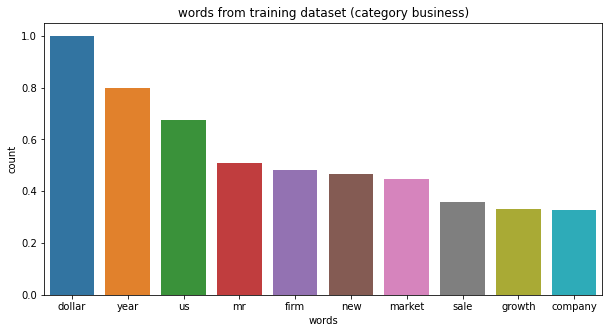

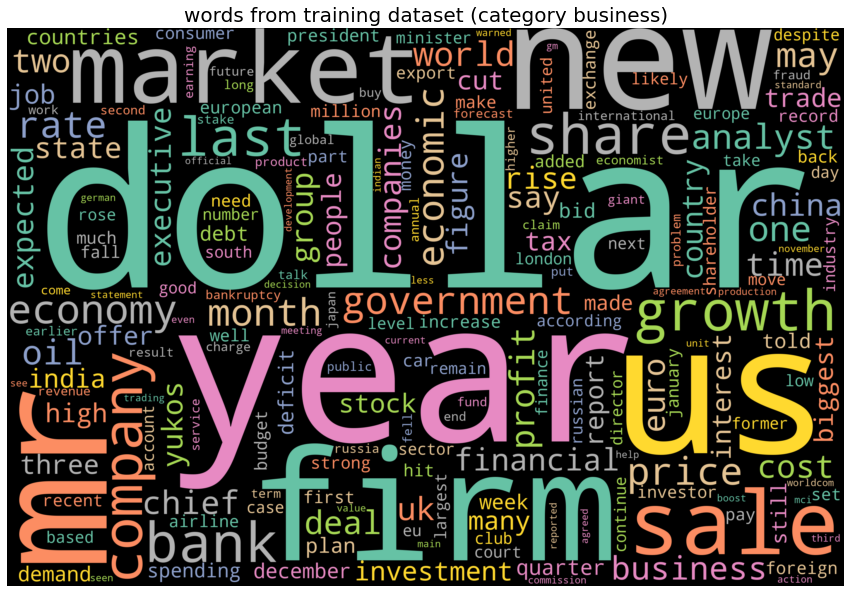

category tech, top 10 words: ['people', 'new', 'mobile', 'phone', 'game', 'service', 'one', 'year', 'mr', 'user']


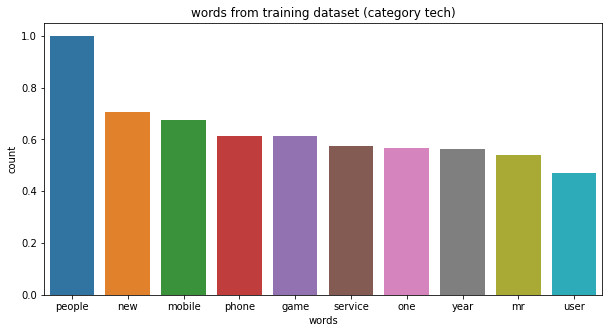

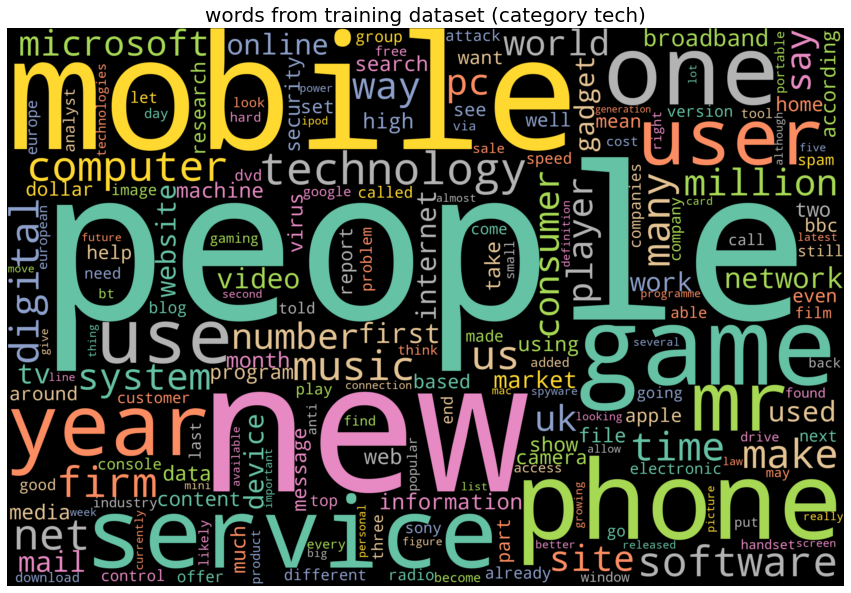

category politics, top 10 words: ['mr', 'labour', 'election', 'government', 'blair', 'party', 'minister', 'people', 'new', 'say']


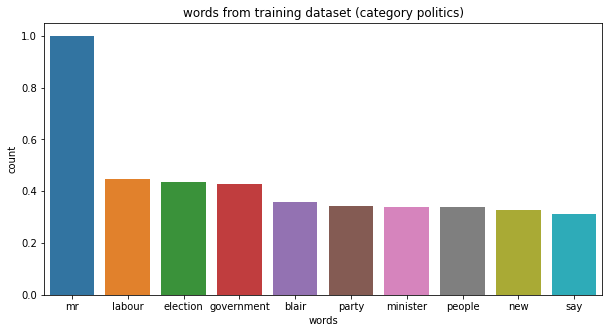

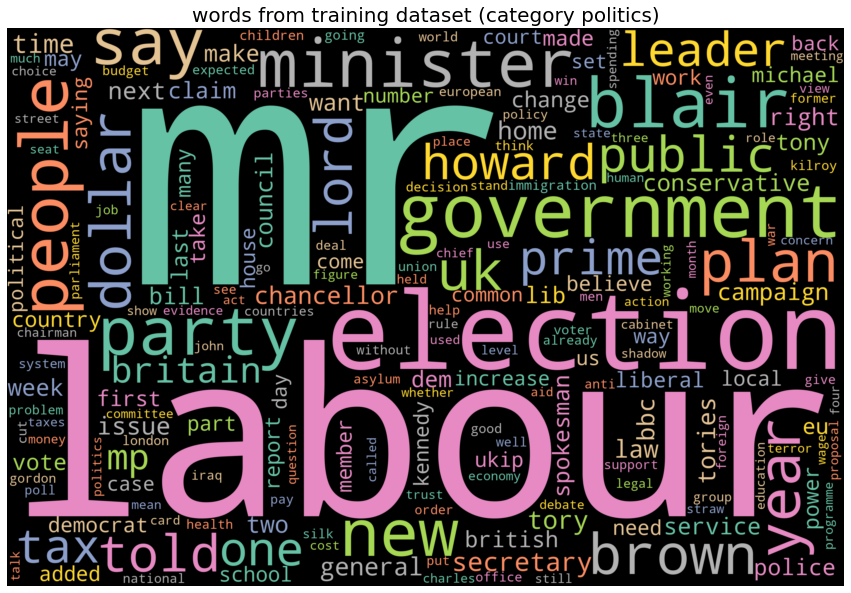

category sport, top 10 words: ['game', 'year', 'first', 'win', 'time', 'england', 'player', 'two', 'back', 'world']


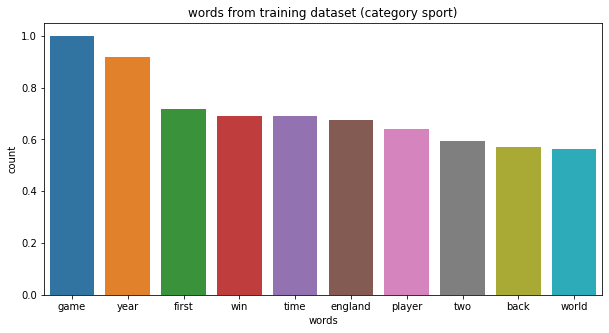

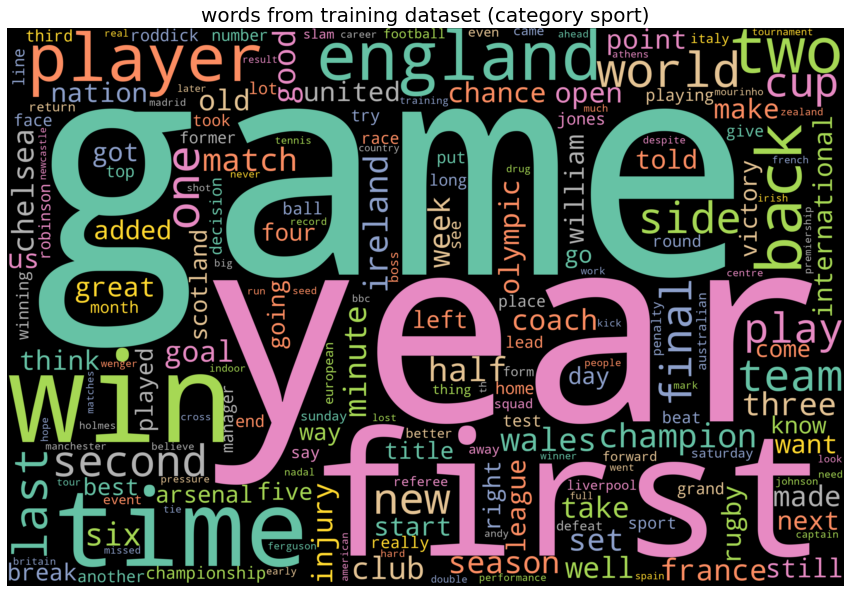

category entertainment, top 10 words: ['film', 'year', 'best', 'award', 'one', 'show', 'new', 'us', 'star', 'music']


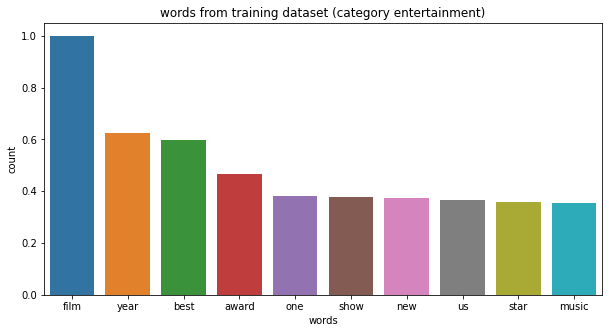

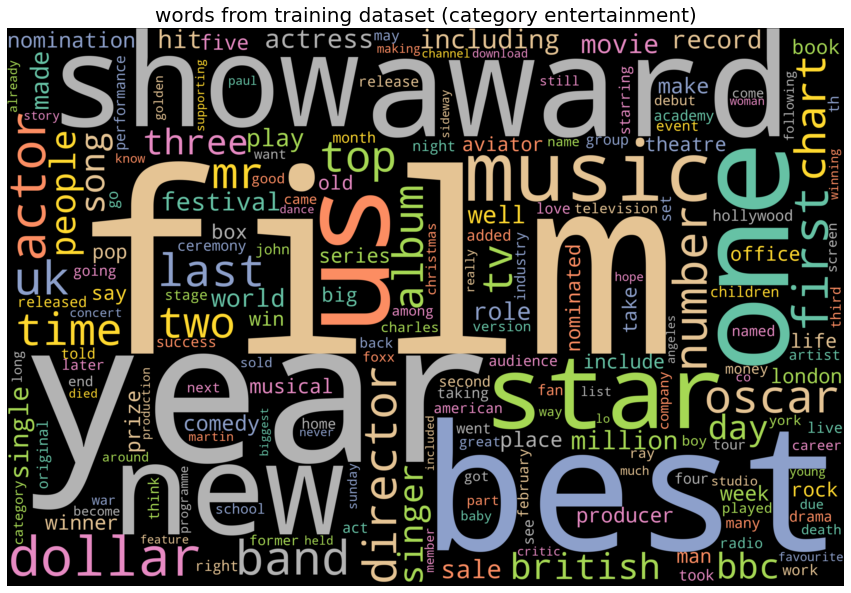

In [81]:
for cat in df_train['Category'].unique():
    plot_wordcloud(' '.join(df_train[df_train['Category']==cat]['Text'].values), f'words from training dataset (category {cat})')

As can be seen from the below output, the topics can be clearly mapped to the following categories.

In [81]:
topic_dict = {0: 'sport', 1: 'politics', 2: 'business', 3: 'entertainment', 4: 'tech'}

In [79]:
nmf.reconstruction_err_ 

35.75224975364894

### Measure the performances of predictions

Let's predict the categories of the articles in the training and validation dataset, using the `NMF` model. As can be seen, both training and validation **accuracies** obtained are pretty descent this time.

In [82]:
print(compute_pred_accuracy(y_train_, get_predictions(nmf, X_train_,  tvectorizer, topic_dict)))
print(compute_pred_accuracy(y_val_, get_predictions(nmf, X_val_, tvectorizer, topic_dict)))

0.9038031319910514
0.8993288590604027


The next **confusion matrix** corresponding to the classification of the validation dataset by the model is shown beow, which also indicates that the classifier does a nice job.

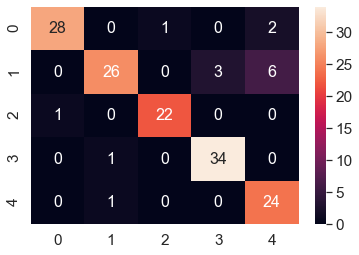

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import matplotlib.pylab as plt

def plot_confusion_matrix(m, k=5):
    df_cm = pd.DataFrame(m, range(k), range(k))
    # plt.figure(figsize=(10,7))
    sns.set(font_scale=1.4) # for label size
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16}) # font size
    plt.show()

plot_confusion_matrix(confusion_matrix(y_val_, get_predictions(nmf, X_val_, tvectorizer, topic_dict)))

Let's train the model (with same hyperarameters) on the entire training dataset and extract the $5$ latent topics again. 

In [85]:
vectors = tvectorizer.fit_transform(X_train).todense() # (documents, vocab)
vocab = np.array(tvectorizer.get_feature_names_out())

nmf = decomposition.NMF(
    n_components=k, 
    random_state=0, 
    init = "nndsvda", 
    beta_loss="frobenius",
    alpha_W=0.001,
    alpha_H=0.001
    )

nmf.fit(vectors)
show_words_for_topics(nmf.components_)

array([['england', 'game', 'win', 'wales', 'ireland', 'cup', 'play',
        'team', 'france', 'time'],
       ['mr', 'labour', 'election', 'blair', 'brown', 'party',
        'government', 'minister', 'howard', 'tax'],
       ['mobile', 'people', 'music', 'phone', 'digital', 'technology',
        'phones', 'users', 'software', 'microsoft'],
       ['film', 'best', 'awards', 'award', 'actor', 'oscar', 'actress',
        'films', 'director', 'festival'],
       ['dollar', 'growth', 'economy', 'year', 'sales', 'economic',
        'market', 'bank', 'oil', 'china']], dtype=object)

Map the topics extracted to categories from the words belonging to the topics.

In [86]:
topic_dict = {0: 'sport', 1: 'politics', 2: 'tech', 3: 'entertainment', 4: 'business'}

Predict the topics of the articles the test dataset, print the first $5$ predictions.

In [90]:
predictions = get_predictions(nmf, X_test, tvectorizer, topic_dict)
print(predictions[:5])

['sport', 'tech', 'sport', 'business', 'sport']


Finally, let's save and submit the predictions to `Kaggle` (late submission!). 

In [137]:
def predict_save(predictions, submission_file='submission_df.csv'):
    submission_df = pd.read_csv('BBC News Sample Solution.csv')
    submission_df['Category'] = predictions
    submission_df.to_csv(submission_file, index=False)
    submission_df.head()
    return submission_df

In [92]:
predict_save(predictions)

,ArticleId,Category
0,1018,sport
1,1319,tech
2,1138,sport
3,459,business
4,1020,sport


### Kaggle submission accuracy scores on test articles classification with unsupervised NMF

The following figure shows test accuracy scores obtained on submission. The submissions could not be selected for leaderboard, since the due date is over.

![](kaggle_submission_0.png)

### Hyperparamter Tuning for NMF

Let's now try to improve the performance (**accuracy**) of classification by tuning a few hyperparamaters for the NMF model

#### 1. Tuning the feature extraction methods

* Let's use **bag-of-words** features (`CountVectorizer`), instead of **tf-idf** features (`TfIdfVectorizer`), but the **validation accuracy** decreases, as shown in the next code snippet.

In [121]:
vectors = cvectorizer.fit_transform(X_train_).todense() # (documents, vocab)
vocab = np.array(cvectorizer.get_feature_names_out())

nmf = decomposition.NMF(
        n_components=k, 
        random_state=0, 
        init = "nndsvda", 
        beta_loss="frobenius",
        alpha_W=0.001,
        alpha_H=0.001
    )

nmf.fit(vectors)
print(show_words_for_topics(nmf.components_))

topic_dict = {0: 'tech', 1: 'politics', 2: 'business', 3: 'entertainment', 4: 'sport'}
print(compute_pred_accuracy(y_val_, get_predictions(nmf, X_val_,  tvectorizer, topic_dict)))

[['people' 'mobile' 'music' 'new' 'technology' 'digital' 'tv' 'like'
  'year' 'phone']
 ['mr' 'labour' 'party' 'blair' 'election' 'brown' 'government' 'new'
  'minister' 'kilroy']
 ['dollar' 'wage' 'minimum' 'increase' 'government' 'people' 'year' 'pay'
  'tax' 'business']
 ['film' 'best' 'actor' 'director' 'actress' 'awards' 'aviator' 'year'
  'foxx' 'jamie']
 ['game' 'roddick' 'nadal' 'england' 'set' 'time' 'world' 'break' 'year'
  'win']]
0.7046979865771812


#### 2. Tuning Regularization Hyperparameters for **NMF**

* Let's tune the **hyperparameters** for `NMF` (e.g., with different values of the **regularization** hyperparameters `alpha_W` and `alpha_H`, different values of `init` and `beta-loss`) to obtain a few different test accuracy scores on `kaggle` for test article classification (shown abobe). 
* One such hyperparameter tuning result is shown below (with `alpha_W=alpha_H=0`), with $~91\%$ **validation accuracy**.

In [98]:
nmf = decomposition.NMF(
        n_components=k, 
        random_state=0, 
        init = "nndsvda", 
        beta_loss="frobenius",
        alpha_W=0,
        alpha_H=0
    )

nmf.fit(vectors)
print(show_words_for_topics(nmf.components_))

topic_dict = {0: 'sport', 1: 'politics', 2: 'business', 3: 'entertainment', 4: 'tech'}
print(compute_pred_accuracy(y_val_, get_predictions(nmf, X_val_,  tvectorizer, topic_dict)))

[['england' 'game' 'win' 'wales' 'cup' 'ireland' 'team' 'france' 'half'
  'play']
 ['mr' 'labour' 'blair' 'election' 'brown' 'party' 'government'
  'minister' 'howard' 'prime']
 ['dollar' 'growth' 'economy' 'sales' 'year' 'bank' 'economic' 'market'
  'china' 'oil']
 ['film' 'best' 'awards' 'award' 'actor' 'oscar' 'actress' 'films'
  'director' 'star']
 ['mobile' 'people' 'music' 'phone' 'digital' 'technology' 'users'
  'broadband' 'software' 'microsoft']]
0.912751677852349


* The next code snippet changes the values of the regularization hyperparamaters for trainign the NMF model and shows the validation accuracy in a tabular form.

In [101]:
vectors = tvectorizer.fit_transform(X_train_).todense() # (documents, vocab)
vocab = np.array(tvectorizer.get_feature_names_out())
acc_df = pd.DataFrame(columns=['alpha_W', 'alpha_H', 'accuracy'])
i = 0
for aW in [0, 0.0001, 0.001]:
    for aH in [0, 0.0001, 0.001]:
        nmf = decomposition.NMF(n_components=k, random_state=0, 
                                init = "nndsvda", beta_loss="frobenius",
                                alpha_W=aW, alpha_H=aH)

        nmf.fit(vectors)
        acc = compute_pred_accuracy(y_val_, get_predictions(nmf, X_val_,  tvectorizer, topic_dict))
        acc_df = acc_df.append({'alpha_W': aW, 'alpha_H': aH, 'accuracy': acc}, ignore_index=True)
#acc_df.head(10)
acc_df = acc_df.pivot(index='alpha_W', columns='alpha_H', values='accuracy')
acc_df.head()

alpha_H,0.0000,0.0001,0.0010
alpha_W,,,
0.0000,0.912752,0.906040,0.906040
0.0001,0.892617,0.899329,0.899329
0.0010,0.892617,0.899329,0.899329


### Visualization

Let's now plot the result of the above hyperparameter tuning, the accuracy obtained on validation split, using the predictions from the NMF model trained on the training split with different regularization hyperparameter values.

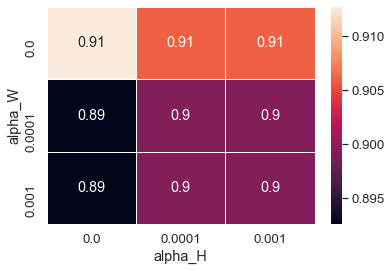

In [105]:
sns.set(font_scale=1.2)
sns.heatmap(acc_df, annot=True, linewidth=.5) 
plt.show()

## Supervised (Multi-class) Classification Models

Now, let's use the catgories as labels from the training dataset provided, to train a few supervised multi-class classification models on the training dataset and use them to predict the categories of the news articles from the test dataset. 

### Preprocessing

To start with, let's preprocess the labels in the training dataset to get a **OHE** (one-hot-encoding) of the labels from the training dataset.

In [110]:
le = LabelEncoder()
y_train = df_train['Category'].values
y_train = le.fit_transform(y_train)
X_train, X_test = df_train['Text'].values, df_test['Text'].values

Extract (**tf-idf**) features prior to building the models, same way it's done for the unsupervised case.

In [111]:
from time import time

def load_data_preprocess(train, test):
    t0 = time()
    vectorizer = TfidfVectorizer(sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english")
    X_train = vectorizer.fit_transform(train.Text.values)
    y_train = train.Category.values
    feature_names = vectorizer.get_feature_names_out()
    target_names = list(set(y_train))
    duration_train = time() - t0
    print('feature extraction time (train)',duration_train)
    # Extracting features from the test data using the same vectorizer
    t0 = time()
    X_test = vectorizer.transform(test.Text.values)
    duration_test = time() - t0
    print('feature extraction time (test)', duration_test)    
    return X_train, X_test, y_train, feature_names, target_names

X_train, X_test, y_train, feature_names, target_names = load_data_preprocess(df_train, df_test)
X_train.shape, y_train.shape, X_test.shape, len(feature_names), len(target_names)

feature extraction time (train) 0.37398338317871094
feature extraction time (test) 0.1562330722808838


((1490, 6852), (1490,), (735, 6852), 6852, 5)

### RidgeClassifier model

Let's train the `RidgeClassifier` linear model on the training dataset. 

### Model Evaluation and Selection

#### 1. with Validation dataset

As before, we shall split the training dataset into two parts, namely a training (to train the model) and a validation (held out to evaluate the trained model) split. First start by instantiating a `Ridge` classifier object, train the model on the training split and then evaluate the performance of the model (in terms of accuracy) both on train split and on the validation dataset.

accuracy on training:  1.0
accuracy on validation:  0.9839142091152815


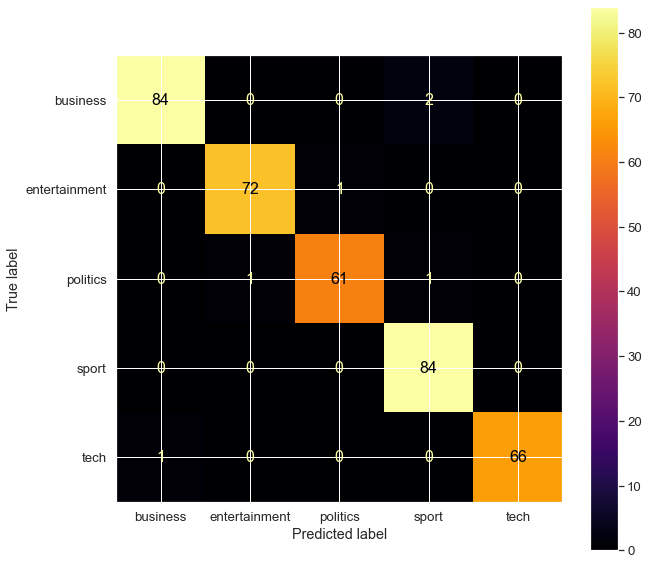

In [112]:
from sklearn.metrics import plot_confusion_matrix
from sklearn.linear_model import RidgeClassifier

X_train_, X_val_, y_train_, y_val_ = train_test_split(X_train, y_train, random_state=0)

clf = RidgeClassifier(tol=1e-2, solver="sparse_cg")

clf.fit(X_train_, y_train_)
print('accuracy on training: ', clf.score(X_train_, y_train_))
print('accuracy on validation: ', clf.score(X_val_, y_val_))

fig, ax = plt.subplots(figsize=(10, 10))
plt.rcParams.update({'font.size': 16})
plot_confusion_matrix(clf, X_val_, y_val_, cmap='inferno', ax=ax)  
plt.show()

#### 2. with 5-fold cross-validation

Now, let's try $k=5$ fold cross-validation and report the accuracies on the validation folds.

In [25]:
from sklearn.model_selection import cross_val_score

cross_val_score(estimator=clf, X=X_train, y=y_train, cv=5)

array([0.96979866, 0.96308725, 0.98657718, 0.98322148, 0.98322148])

Since the classfier obtains pretty good performance on the vaidation dataset, let's train it on the whole training dataset and use the trained model to predict the categories of the articles from the test dataset. Write the predictions in a csv file and submit it `kaggle`.

In [138]:
def train_predict(clf, X_train, y_train, X_test):
    # train
    clf.fit(X_train, y_train)
    # predict on train
    pred = clf.predict(X_train)
    print(f'training accuracy: {np.mean(pred == y_train)}') # compute accuracy
    # predict on test
    pred = clf.predict(X_test)
    return pred

In [114]:
pred_df = predict_save(train_predict(clf, X_train, y_train, X_test), 'learn-ai-bbc/BBC News RidgeClassifier Solution.csv')
pred_df.head()

training accuracy: 1.0


,ArticleId,Category
0,1018,sport
1,1319,tech
2,1138,sport
3,459,business
4,1020,sport


As we can see, the accuracy of the ridge classifier model on the training dataset is $100\%$. However, when the prediction on the test dataset was submitted `Kaggle`. it obtained $98.5\%$ test accuracy score on `kaggle` for classification of the articles from the unseen dataset. 

### Visualizing the Decision Boundaries for Classification

Let's visualize the decision boundaries for the categories using the linear model with 2D `t-SNE` projection. 

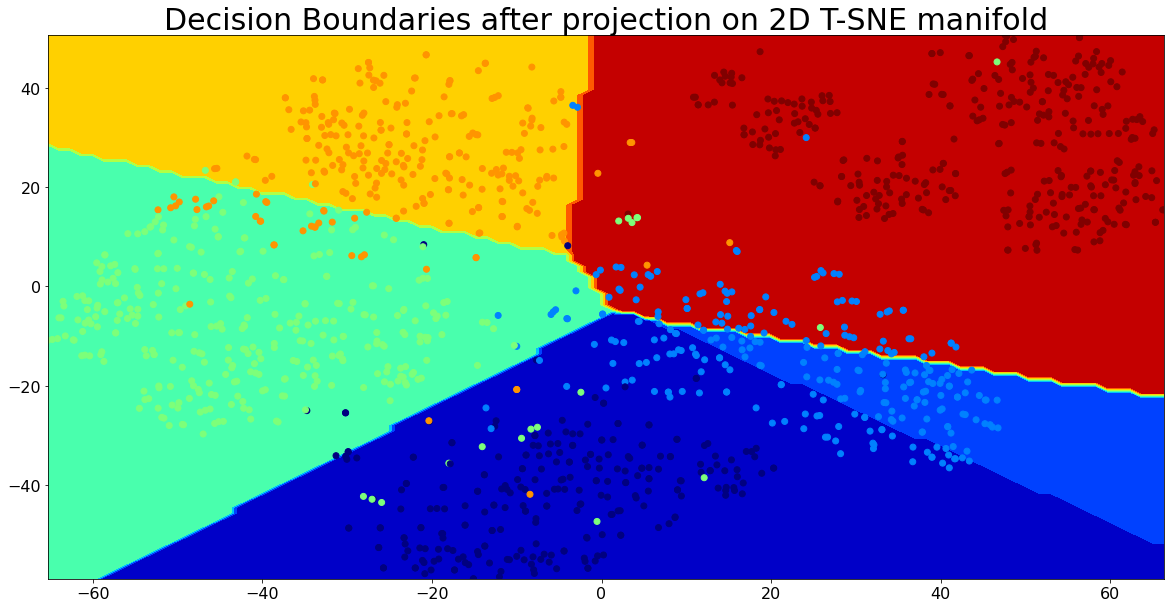

In [62]:
from sklearn.manifold import TSNE

X_train_embedding = TSNE(n_components=2).fit_transform(X_train)
resolution = 100 # 100x100 background pixels
X2d_xmin, X2d_xmax = np.min(X_train_embedding[:,0]), np.max(X_train_embedding[:,0])
X2d_ymin, X2d_ymax = np.min(X_train_embedding[:,1]), np.max(X_train_embedding[:,1])
xx, yy = np.meshgrid(np.linspace(X2d_xmin, X2d_xmax, resolution), np.linspace(X2d_ymin, X2d_ymax, resolution))
background_model = clf.fit(X_train_embedding, clf.predict(X_train)) 
vbg = background_model.predict(np.c_[xx.ravel(), yy.ravel()])
vbg = vbg.reshape((resolution, resolution))
colors = {name: color for (name, color) in zip(target_names, range(len(target_names)))}
plt.figure(figsize=(20,10))
plt.contourf(xx, yy, np.array([colors[x] for x in vbg.ravel()]).reshape(vbg.shape), cmap='jet')
plt.scatter(X_train_embedding[:,0], X_train_embedding[:,1], c=np.array([colors[y] for y in y_train]), cmap='jet')
plt.title('Decision Boundaries after projection on 2D T-SNE manifold', size=30)
plt.show()

### Hyperparameter Tuning With GridSearchCV

Now, let's try `GridSearchCV` for hyperparameter tuning and model selection, for `RidgeClassifier`, `SVC` (support vector classifier), `random forest` and `gradient boosting` ensemble classifier models.


####  1. RidgeClassifier Model

In [83]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

def tune_hyperparameters(clf, param_grid, X_train, y_train, X_val, y_val):    
    grid = GridSearchCV(clf, param_grid, refit = True, verbose = 3, n_jobs=-1) 
    grid.fit(X_train, y_train) 
    print('Bets params:', grid.best_params_) 
    grid_pred = grid.predict(X_val) 
    print('val score:', grid.score(X_val, y_val))    
    print(classification_report(y_val, grid_pred))     

tune_hyperparameters(RidgeClassifier(tol=1e-2, solver="sparse_cg"), 
                     {'alpha': [1, 0.1, 0.01, 0.001, 0.0001, 0]}, 
                     X_train_, y_train_, X_val_, y_val_)  

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Bets params: {'alpha': 1}
val score: 0.9839142091152815
               precision    recall  f1-score   support

     business       1.00      0.98      0.99        86
entertainment       0.97      0.99      0.98        73
     politics       0.98      0.97      0.98        63
        sport       0.97      1.00      0.98        84
         tech       1.00      0.99      0.99        67

     accuracy                           0.98       373
    macro avg       0.98      0.98      0.98       373
 weighted avg       0.98      0.98      0.98       373



In [84]:
predict_save(train_predict(RidgeClassifier(tol=1e-2, alpha=1, solver="sparse_cg"), X_train, y_train, X_test), 
              output_file='learn-ai-bbc/BBC RidgeClassifier Solution.csv') 

#### 2. Support Vector Classfier Model

In [69]:
from sklearn.svm import SVC    
tune_hyperparameters(SVC(), 
                     {'C': [0.1, 1, 10, 100],  
                      'gamma':['scale', 'auto'],
                      'kernel': ['linear', 'rbf']}, 
                      X_train_, y_train_, X_val_, y_val_)  

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Bets params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
               precision    recall  f1-score   support

     business       0.99      0.98      0.98        86
entertainment       0.96      0.99      0.97        73
     politics       0.97      0.95      0.96        63
        sport       0.99      0.99      0.99        84
         tech       0.99      0.99      0.99        67

     accuracy                           0.98       373
    macro avg       0.98      0.98      0.98       373
 weighted avg       0.98      0.98      0.98       373



Now, let's train the SVC model with the best hyperparameters obtained, this time on the entire training dataset and then make a prediction on the unseen test dataset, so that we shall be ready for another submission. 

In [85]:
predict_save(train_predict(SVC(C=10, gamma='scale', kernel="linear"), X_train, y_train, X_test), 
              output_file='learn-ai-bbc/BBC News SVC Solution.csv')) 

A few more ensemble classifier models (e.g., **Random Forest**, **Gradient Boosting** and **Stacked Ensemble** classifier models) were trained on the training dataset and then used to predict the test article categories. 

### Kaggle submission accuracy scores on test articles classification with supervised models

The following screenshot shows accuracy scores obtained on `kaggle` on the unseen test dataset for different supervised models. The score obtained on the unseen test dataset was much less than the accuracy obtained on the training dataset with the **GBM** model, which implies the model **overfitted** on the training dataset more than other models. 

![](kaggle_submission_2.png)

### Comparing the results obtained with supervised classifiers with those with the unsupervised NMF

* As can be seen from the above result, the supervised multi-class classification models outperform the unsupervised models based on matrix-factorization and topic modeling.
* The unsupervised approach (**NMF**) obtained maximum of $~91\%$ score, whereas with supervised approach obtained $~97\%$ score on the unseen test dataset.
* The **Linear Support Vector Classifier** and the **Stacked Ensemble Classifier** performed the best on the unseen dataset.

Now, let's try changing the train data size and observe train / test performance changes to note which of the methods (supervised vs. unsupervised) are **data-efficient** (require a smaller amount of data to achieve similar results) and which of the methods are prone to less **overfitting**.

In [142]:
X_train, y_train = df_train['Text'].values, df_train['Category'].values
X_train_, X_val_, y_train_, y_val_ = train_test_split(X_train, y_train, random_state=0)
n_feats = 5000
tvectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2, max_features=n_feats) #, tokenizer=LemmaTokenizer())
train_vectors = tvectorizer.fit_transform(X_train_)
vocab = np.array(tvectorizer.get_feature_names_out())
test_vectors = tvectorizer.transform(X_val_)
n_train = len(X_train_)
k = 5
topic_dicts = {
              1: {0: 'business', 1: 'politics', 2: 'sport', 3: 'tech', 4: 'entertainment'},
              0.5: {0: 'tech', 1: 'politics', 2: 'sport', 3: 'entertainment', 4: 'business'},
              0.2: {0: 'politics', 1: 'sport', 2: 'business', 3: 'entertainment', 4: 'tech'},
              0.1: {0: 'business', 1: 'tech', 2: 'sport', 3: 'politics', 4: 'entertainment'}
              }
np.random.seed(0)
for p in [1, 0.5, 0.2, 0.1]:
    train_indices = np.random.choice(n_train, int(n_train * p))
    X_train_sub, y_train_sub = train_vectors[train_indices], y_train_[train_indices]
    print(p, X_train_.shape, X_train_sub.shape)
    # supervised
    print('supervised SVC')
    print('test accuracy: {}'.format(
         compute_pred_accuracy(y_val_, train_predict(SVC(), X_train_sub, y_train_sub, test_vectors))))
    # unsupervised
    print('unsupervised NMF')
    nmf = decomposition.NMF(n_components = k, random_state = 0, 
                            init = "nndsvda", beta_loss = "frobenius",
                            alpha_W = 0.001, alpha_H = 0.001)
    nmf.fit(X_train_sub)
    #print(show_words_for_topics(nmf.components_))
    topic_dict = topic_dicts[p]
    print('training accuracy: {}'.format(
          compute_pred_accuracy(y_train_sub, get_predictions(nmf, X_train_[train_indices], tvectorizer, topic_dict)))
    )
    print('test accuracy: {}'.format(
          compute_pred_accuracy(y_val_, get_predictions(nmf, X_val_, tvectorizer, topic_dict))))

1 (1117,) (1117, 5000)
supervised SVC
training accuracy: 1.0
test accuracy: 0.967828418230563
unsupervised NMF
training accuracy: 0.9131602506714414
test accuracy: 0.8981233243967829
0.5 (1117,) (558, 5000)
supervised SVC
training accuracy: 1.0
test accuracy: 0.9463806970509383
unsupervised NMF
training accuracy: 0.899641577060932
test accuracy: 0.900804289544236
0.2 (1117,) (223, 5000)
supervised SVC
training accuracy: 1.0
test accuracy: 0.9168900804289544
unsupervised NMF
training accuracy: 0.7309417040358744
test accuracy: 0.6702412868632708
0.1 (1117,) (111, 5000)
supervised SVC
training accuracy: 1.0
test accuracy: 0.5361930294906166
unsupervised NMF
training accuracy: 0.6036036036036037
test accuracy: 0.5710455764075067


In [136]:
X_train, y_train, X_test = df_train['Text'].values, df_train['Category'].values, df_test['Text'].values
n_feats = 5000
tvectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2, max_features=n_feats) #, tokenizer=LemmaTokenizer())
train_vectors = tvectorizer.fit_transform(X_train)
vocab = np.array(tvectorizer.get_feature_names_out())
test_vectors = tvectorizer.transform(X_test)
n_train = len(X_train)
k = 5
topic_dict = {0: 'sport', 1: 'politics', 2: 'tech', 3: 'entertainment', 4: 'business'}
np.random.seed(0)
for p in [1, 0.5, 0.2, 0.1]:
    train_indices = np.random.choice(n_train, int(n_train * p))
    X_train_sub, y_train_sub = train_vectors[train_indices], y_train[train_indices]
    print(p, X_train.shape, X_train_sub.shape)
    # supervised
    print('supervised SVC')
    train_predict(SVC(), X_train_sub, y_train_sub, test_vectors, f'learn-ai-bbc/BBC News SVC Solution - {p}.csv')
    # unsupervised
    print('unsupervised NMF')
    nmf = decomposition.NMF(n_components = k, random_state = 0, 
                            init = "nndsvda", beta_loss = "frobenius",
                            alpha_W = 0.001, alpha_H = 0.001)
    nmf.fit(train_vectors)
    #print(show_words_for_topics(nmf.components_))
    #topic_dict = {0: 'sport', 1: 'politics', 2: 'tech', 3: 'entertainment', 4: 'business'}
    print('training accuracy: {}'.format(
          compute_pred_accuracy(y_train_sub, get_predictions(nmf, X_train[train_indices], tvectorizer, topic_dict)))
    )
    predict_save(get_predictions(nmf, X_test, tvectorizer, topic_dict), f'learn-ai-bbc/BBC News NMF Solution - {p}.csv')

1 (1490,) (1490, 5000)
supervised SVC
training accuracy: 1.0
unsupervised NMF
training accuracy: 0.9060402684563759
0.5 (1490,) (745, 5000)
supervised SVC
training accuracy: 1.0
unsupervised NMF
training accuracy: 0.8966442953020134
0.2 (1490,) (298, 5000)
supervised SVC
training accuracy: 1.0
unsupervised NMF
training accuracy: 0.9161073825503355
0.1 (1490,) (149, 5000)
supervised SVC
training accuracy: 1.0
unsupervised NMF
training accuracy: 0.9194630872483222


In [ ]:
red_df = pd.DataFrame({'train data percent': [100, 50, 20, 10], 
                       'SVC acc train': [1, 1, 1, 1],
                       'NMF acc train': [0.906, 0.8966, 0.916, 0.919],
                       'SVC acc test': [1, 1, 1, 1],
                       'NMF acc test': [0.906, 0.8966, 0.916, 0.919]})

# Part 2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.model_selection import train_test_split
from scipy.sparse import coo_matrix, csr_matrix
from scipy.spatial.distance import jaccard, cosine 
from pytest import approx

In [14]:
MV_users = pd.read_csv('data/users.dat', sep='::', encoding='latin-1', names=['uid', 'gender', 'age', 'occu', 'zip'], header=None)
MV_movies = pd.read_csv('data/movies.dat', sep='::', encoding='latin-1', names=['mid', 'name', 'genre'], header=None)
MV_ratings = pd.read_csv('data/ratings.dat', sep='::', encoding='latin-1', names=['uid', 'mid', 'rating', 'time'], header=None)

C:\Users\Sandipan.Dey\anaconda3\lib\site-packages\pandas\util\_decorators.py:311: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  return func(*args, **kwargs)


In [19]:
print(MV_users.shape, MV_movies.shape, MV_ratings.shape)
MV_ratings.head()

(6040, 5) (3883, 3) (1000209, 4)


,uid,mid,rating,time
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [64]:
ratings = MV_ratings.pivot(index='uid', columns='mid', values='rating')
print(ratings.shape)
ratings.head()

(6040, 3706)


mid,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
uid,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
missing_locs = np.isnan(ratings)
#ratings[missing_locs] = 0
mean = ratings.apply(np.nanmean, axis=0)
ratings.fillna(mean, inplace=True)
ratings.head()

mid,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
uid,,,,,,,,,,,,,,,,,,,,,
1,5.000000,3.201141,3.016736,2.729412,3.006757,3.878723,3.41048,3.014706,2.656863,3.540541,...,3.052083,2.111111,1.488372,2.26,3.472727,3.635731,4.115132,3.666667,3.9,3.780928
2,4.146846,3.201141,3.016736,2.729412,3.006757,3.878723,3.41048,3.014706,2.656863,3.540541,...,3.052083,2.111111,1.488372,2.26,3.472727,3.635731,4.115132,3.666667,3.9,3.780928
3,4.146846,3.201141,3.016736,2.729412,3.006757,3.878723,3.41048,3.014706,2.656863,3.540541,...,3.052083,2.111111,1.488372,2.26,3.472727,3.635731,4.115132,3.666667,3.9,3.780928
4,4.146846,3.201141,3.016736,2.729412,3.006757,3.878723,3.41048,3.014706,2.656863,3.540541,...,3.052083,2.111111,1.488372,2.26,3.472727,3.635731,4.115132,3.666667,3.9,3.780928
5,4.146846,3.201141,3.016736,2.729412,3.006757,2.000000,3.41048,3.014706,2.656863,3.540541,...,3.052083,2.111111,1.488372,2.26,3.472727,3.635731,4.115132,3.666667,3.9,3.780928


In [75]:
k = 10
nmf = decomposition.NMF(
    n_components=k, 
    random_state=0, 
    init = "nndsvda", 
    beta_loss="frobenius",
    alpha_W=0.001,
    alpha_H=0.001,
    )

W1 = nmf.fit_transform(ratings)
H1 = nmf.components_
nmf.reconstruction_err_

949.1002008605132

In [78]:
from sklearn.metrics import mean_squared_error as mse
pred = W1 @ H1
pred[missing_locs] = 0
#np.sqrt(mse(ratings, pred))
np.sqrt(np.sum((ratings.values[~missing_locs] - pred[~missing_locs])**2) / (np.sum(~missing_locs.values)))

0.9346335330327447